In [ ]:
import planetary_computer
from pystac_client import Client
import stackstac
import xarray as xr
import rioxarray as rio
import numpy as np
import pandas as pd
import geopandas as gpd
from rasterio.enums import Resampling
from rasterio.errors import RasterioIOError
import os
from bld_src import config

from osgeo import gdal
# GDAL configurations
gdal.SetConfigOption('GDAL_HTTP_COOKIEFILE','~/cookies.txt')
gdal.SetConfigOption('GDAL_HTTP_COOKIEJAR', '~/cookies.txt')
gdal.SetConfigOption('GDAL_DISABLE_READDIR_ON_OPEN','EMPTY_DIR')
#gdal.SetConfigOption('CPL_VSIL_CURL_ALLOWED_EXTENSIONS','TIF')
gdal.SetConfigOption('GDAL_HTTP_UNSAFESSL', 'YES')
gdal.SetConfigOption('GDAL_HTTP_MAX_RETRY', '10')
gdal.SetConfigOption('GDAL_HTTP_RETRY_DELAY', '10')

gdal.SetConfigOption('CPL_VSIL_CURL_ALLOWED_EXTENSIONS','.tif,.tiff')

In [58]:
b = gpd.read_file(config.DATA_PROCESSED / 'justin_plots_polygons.gpkg')

In [59]:
boundary = b.loc[b['Site']=='Rockefeller State Park'].copy()

In [60]:
boundary

,Site,Name,geometry
10,Rockefeller State Park,BLD-NY-RSP-02,"POLYGON ((598733.308 4552010.143, 598733.252 4..."
11,Rockefeller State Park,BLD-NY-RSP-01,"POLYGON ((598669.466 4551982.292, 598669.41 45..."


In [63]:


res = 10
epsg = 26918
bands = ['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12']


bbox_4326 = tuple(boundary.to_crs(4326).total_bounds)
bbox_utm = tuple(boundary.total_bounds)


catalog = Client.open(
     "https://planetarycomputer.microsoft.com/api/stac/v1", 
     modifier=planetary_computer.sign_inplace,
)

years = [2018,2019,2020,2021,2022,2023,2024,2025,2026]

In [64]:

scaled_data = []
for year in years:
    items = catalog.search(                    
            bbox=bbox_4326, 
            collections=["sentinel-2-l2a"],
            datetime=f"{year}-07-01/{year}-08-30"
        ).item_collection()
    print(f'{year} found {len(items)} images')
    if len(items) == 0:
            continue

    # drop reprocessing duplicates: same tile and acquisition, keep newest baseline
    df = pd.DataFrame([{
            'id': i.id, 'datetime': i.datetime,
            'tile': i.properties.get('s2:mgrs_tile'),
            'baseline': float(i.properties.get('s2:processing_baseline')),
        } for i in items])
    keep = set(df.sort_values('baseline', ascending=False)
                        .drop_duplicates(['tile', 'datetime'], keep='first')['id'])
    sel = [i for i in items if i.id in keep]

    ref = stackstac.stack(
            sel, epsg=epsg, resolution=res, bounds=bbox_utm,
            assets=bands, resampling=Resampling.bilinear, rescale=False,
            errors_as_nodata=(RasterioIOError,RuntimeError)
        ).drop_attrs().reset_coords(drop=True).astype('float32')

    scl = stackstac.stack(
            sel, epsg=epsg, resolution=res, bounds=bbox_utm,
            assets=['SCL'], resampling=Resampling.nearest,errors_as_nodata=(RasterioIOError,RuntimeError)
        ).drop_attrs().reset_coords(drop=True).astype('uint8')

    mask   = ~scl.sel(band='SCL', drop=True).isin([0, 1, 2, 3, 6, 8, 9, 10, 11])
    masked = ref.where(mask)

    # harmonize the post-baseline-04.00 reflectance offset, then scale
    base   = xr.DataArray([float(i.properties['s2:processing_baseline'])
                                for i in sel], dims='time',
                                coords={'time': masked.time})
    offset = (base >= 4.0).astype('float32')

    scaled = (masked - offset * 1000) / 10000

    ## add indices
    blue  = scaled.sel(band="B02")
    red   = scaled.sel(band="B04")
    #re1   = scaled.sel(band="B05")
    re2   = scaled.sel(band="B06")
    #re3   = scaled.sel(band="B07")
    nir   = scaled.sel(band="B08")
    sw1   = scaled.sel(band="B11")

    eps = 1e-10

    ndmi  = ((nir - sw1) / (nir + sw1 + eps)).expand_dims({'band':['ndmi']})
    evi = 2.5 * ((nir - red) / (nir + 6 * red - 7.5 * blue + 1)).expand_dims({'band':['evi']})

    ndmi_median = ndmi.median(dim='time',skipna=True)
    evi_median = evi.median(dim='time',skipna=True)
    scaled_median = scaled.median(dim='time',skipna=True)

    scaled_with_indices = xr.concat([scaled_median,evi_median,ndmi_median],dim='band')
    

    scaled_data.append(scaled_with_indices)
    
    
medians_all_years = xr.concat(scaled_data, dim='time')
medians_all_years = medians_all_years.assign_coords({'time': years})



        



2018 found 24 images
2019 found 24 images
2020 found 24 images
2021 found 25 images
2022 found 31 images
2023 found 45 images
2024 found 24 images
2025 found 30 images
2026 found 30 images


In [66]:
from exactextract import exact_extract

In [67]:
band_list = medians_all_years.band.values

medians_c = medians_all_years.compute() # materialize dask array
# add spatial info to array
medians_c = medians_c.rio.write_crs(26918).rio.set_spatial_dims(x_dim='x',y_dim='y').rio.write_coordinate_system()

In [68]:


df_list = []
for y in years:
    df_t = exact_extract(medians_c.sel(time=y),boundary,'mean',include_cols=['Name'],output='pandas')
    df_t.columns = ['Site'] + [f'{b}' for b in band_list] 
    df_t['year'] = y
    df_list.append(df_t)


In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

In [70]:
all_data = pd.concat(df_list,axis=0)
all_data['year'] = pd.to_datetime( [f'{d}-07' for d in all_data['year']],format='%Y-%m')

In [78]:
all_data.to_csv(config.DATA_PROCESSED/ 'rockefeller_sites_sentinel.csv')

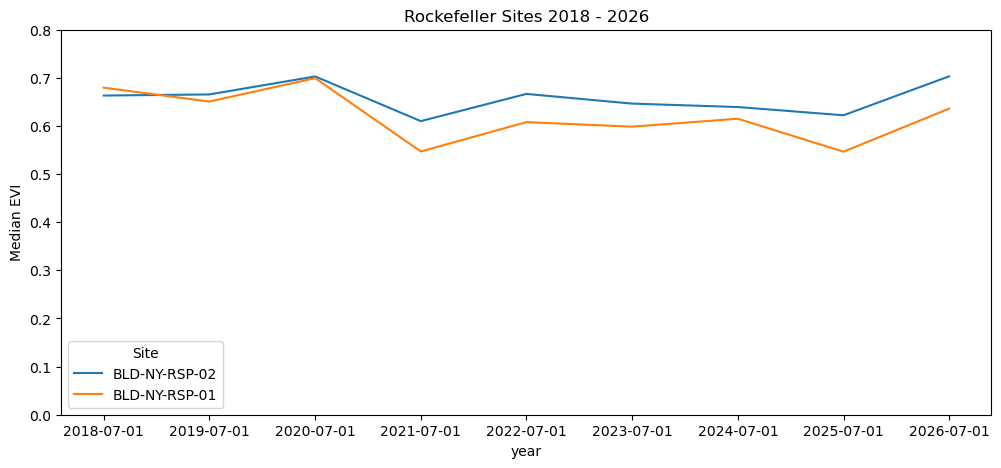

In [81]:
fig, ax = plt.subplots(figsize=(12,5))
ax = sns.lineplot(all_data,x='year',y='evi',hue='Site')
ax.set_xticks(all_data['year'].unique())
ax.set_ylabel('Median EVI')
ax.set_ylim(0,0.8)
ax.set_title('Rockefeller Sites 2018 - 2026')
plt.show()